In [39]:
import sys

sys.path.append("../../v2")
sys.path.append("..")

%load_ext autoreload
%autoreload 2

from pathlib import Path
import re
from scipy.stats import mannwhitneyu,false_discovery_control
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,QuantileTransformer
from arfpy import arf
from tqdm import tqdm

from v0.src import HistogramImputation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data_path = Path("/data1/prostrat-ai/data/peptide_and_clinical_data_v2.csv")
full_df = pl.read_csv(data_path)
full_df = full_df.fill_nan(0.0)
full_df = full_df.fill_null(0.0)

In [3]:
CATEGORICAL_CLINICAL_COLUMNS = [
    "Geschlecht (1=female)",
    "Kidney disease",
    "diabetes",
    "CVD",
    "hypertension",
]

NUMERICAL_CLINICAL_COLUMNS = [
    "Blutdruck, diastolischM",
    "Blutdruck, systolischM",
    "GFR_CKD_EPI_M",
    "BMI_M",
    "Alter_M",
    "time-to-CKDevent(to event or last visit)",
    "FU duration_CAD_Hfevent (to event or last visit)",
]

In [4]:
peptide_patt = re.compile("peptide", re.IGNORECASE)
peptide_cols = [
    col for col in full_df.columns if re.search(peptide_patt, col) is not None
]
non_peptide = [
    col for col in full_df.columns if col not in peptide_cols + ["idAuswertung"]
]

In [5]:
def split_peptide_columns_by_zero_percentage(
    df: pl.DataFrame, zero_perc_threshold: float = 0.3
):
    total_rows = df.height

    # Calculate zero percentages for all columns at once
    zero_percentages = df.select(
        [(pl.col(col) == 0).sum() / total_rows for col in df.columns]
    ).to_dicts()[0]

    above_zero_threshold = [
        col for col, pct in zero_percentages.items() if pct > zero_perc_threshold
    ]
    below_zero_threshold = [
        col for col, pct in zero_percentages.items() if pct <= zero_perc_threshold
    ]
    return below_zero_threshold, above_zero_threshold

In [6]:
below, above = split_peptide_columns_by_zero_percentage(
    full_df.select(peptide_cols), zero_perc_threshold=0.5
)

In [7]:
len(below), len(above)

(1434, 20125)

In [8]:
many_zero_df = full_df.select(above)

In [ ]:
col_statistics = []
num_bins = 5
qunatile_array = np.linspace(0, 1, num_bins)
for col in tqdm(many_zero_df.columns):
    peptide_abundance = many_zero_df.select(col).to_numpy()
    quantiles = np.quantile(peptide_abundance, q=qunatile_array)
    hist, bin_edges = np.histogram(
        peptide_abundance, bins=num_bins  # qunatile_array
    )  # or other binning strategies
    medians = []
    for i in range(len(bin_edges) - 1):
        up, low = bin_edges[i + 1], bin_edges[i]

        bin_idx = np.logical_and(peptide_abundance >= low, peptide_abundance <= up)
        if bin_idx.any():
            medians.append(np.median(peptide_abundance[bin_idx]))
        else:
            medians.append(up)
    bin_edges = bin_edges[
        :-1
    ]  # Remove the last edge, to make bin_edges align with hist.

    col_statistics.append(
        {
            "col": col,
            "density": hist / np.sum(hist),
            "medians": medians,
            "bin_edges": bin_edges,
            "quantiles": quantiles,
        }
    )

100%|██████████| 20125/20125 [00:47<00:00, 425.71it/s]


In [ ]:
imputation = HistogramImputation(column_names=above, num_bins=5)

In [46]:
imputation.fit(full_df.select(above))

Calculating histogram imputation...: 100%|██████████| 20125/20125 [00:45<00:00, 446.01it/s]
2025-03-24 15:21:53.573 | SUCCESS  | src.models.Imputation.HistogramImputation:fit:29 - Imputation done!


In [51]:
cols, data = imputation.generate(2000)

In [53]:
data.shape

(2000, 20125)

1340
[9.99283796e-01 5.37153089e-04 0.00000000e+00 0.00000000e+00
 1.79051030e-04] [    0.    5027.98 10055.96 15083.94 20111.92] [    0.      0.      0.      0.  25139.9]


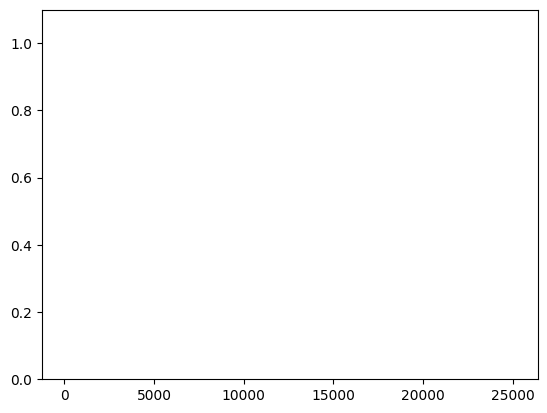

In [31]:
i = np.random.randint(low=0, high=len(col_statistics), size=1)[0]
print(i)
col_stat = col_statistics[i]
len(col_stat["density"]) == len(col_stat["bin_edges"])
plt.bar(x=col_stat["medians"], height=col_stat["density"])
plt.ylim(0, 1.1 * col_stat["density"].max())
print(col_stat["density"], col_stat["bin_edges"], col_stat["quantiles"])

[np.float64(0.0), np.float64(5985.12), np.float64(15083.940000000002), np.float64(20111.920000000002), np.float64(25139.9)] [    0.    5027.98 10055.96 15083.94 20111.92]


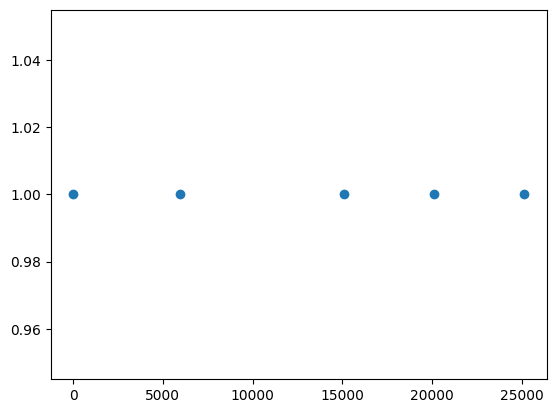

In [ ]:
plt.scatter(col_stat["medians"], np.ones_like(col_stat["medians"]))
print(col_stat["medians"], col_stat["bin_edges"])

In [ ]:
col_stat["density"]

array([9.89615040e-01, 7.87824530e-03, 1.43240824e-03, 7.16204118e-04,
       3.58102059e-04])

In [ ]:
col_stat["density"], col_stat["bin_edges"]

(array([9.99462847e-01, 1.79051030e-04, 0.00000000e+00, 1.79051030e-04,
        1.79051030e-04]),
 array([   0.  ,  661.86, 1323.72, 1985.58, 2647.44]))

In [ ]:
oh_encoder = OneHotEncoder(sparse_output=False)
scaler = QuantileTransformer()  # StandardScaler()  # RobustScaler()

In [ ]:
categorical = full_df.select(CATEGORICAL_CLINICAL_COLUMNS).to_numpy()
numerical = full_df.select(below + NUMERICAL_CLINICAL_COLUMNS).to_numpy()

In [ ]:
categorical_oh = oh_encoder.fit_transform(categorical)
num_oh_cols = categorical_oh.shape[-1]

In [ ]:
original_df = full_df.select(
    below + NUMERICAL_CLINICAL_COLUMNS + CATEGORICAL_CLINICAL_COLUMNS
)

In [ ]:
numerical_scaled = scaler.fit_transform(numerical)

In [ ]:
numerical_feature_names = scaler.get_feature_names_out().tolist()
numerical_feature_names

['x0',
 'x1',
 'x2',
 'x3',
 'x4',
 'x5',
 'x6',
 'x7',
 'x8',
 'x9',
 'x10',
 'x11',
 'x12',
 'x13',
 'x14',
 'x15',
 'x16',
 'x17',
 'x18',
 'x19',
 'x20',
 'x21',
 'x22',
 'x23',
 'x24',
 'x25',
 'x26',
 'x27',
 'x28',
 'x29',
 'x30',
 'x31',
 'x32',
 'x33',
 'x34',
 'x35',
 'x36',
 'x37',
 'x38',
 'x39',
 'x40',
 'x41',
 'x42',
 'x43',
 'x44',
 'x45',
 'x46',
 'x47',
 'x48',
 'x49',
 'x50',
 'x51',
 'x52',
 'x53',
 'x54',
 'x55',
 'x56',
 'x57',
 'x58',
 'x59',
 'x60',
 'x61',
 'x62',
 'x63',
 'x64',
 'x65',
 'x66',
 'x67',
 'x68',
 'x69',
 'x70',
 'x71',
 'x72',
 'x73',
 'x74',
 'x75',
 'x76',
 'x77',
 'x78',
 'x79',
 'x80',
 'x81',
 'x82',
 'x83',
 'x84',
 'x85',
 'x86',
 'x87',
 'x88',
 'x89',
 'x90',
 'x91',
 'x92',
 'x93',
 'x94',
 'x95',
 'x96',
 'x97',
 'x98',
 'x99',
 'x100',
 'x101',
 'x102',
 'x103',
 'x104',
 'x105',
 'x106',
 'x107',
 'x108',
 'x109',
 'x110',
 'x111',
 'x112',
 'x113',
 'x114',
 'x115',
 'x116',
 'x117',
 'x118',
 'x119',
 'x120',
 'x121',
 'x122',
 'x

In [ ]:
oh_feature_names = oh_encoder.get_feature_names_out().tolist()
oh_feature_names

['x0_1.0',
 'x0_2.0',
 'x1_0.0',
 'x1_1.0',
 'x2_0.0',
 'x2_1.0',
 'x3_0.0',
 'x3_1.0',
 'x4_0.0',
 'x4_1.0']

In [ ]:
categorical_oh

array([[0., 1., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 0., 1.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 1., 0.]])

In [ ]:
numerical_scaled

array([[0.        , 0.4972394 , 0.66670659, ..., 0.17517518, 0.        ,
        0.13195202],
       [0.        , 0.43954804, 0.62682962, ..., 0.17517518, 0.66594938,
        0.34884885],
       [0.        , 0.        , 0.        , ..., 0.01701702, 0.        ,
        0.03095019],
       ...,
       [0.90839513, 0.        , 0.        , ..., 0.7957958 , 0.        ,
        0.82282282],
       [0.68453349, 0.87999254, 0.92192025, ..., 0.98535149, 0.        ,
        0.57684235],
       [0.72090281, 0.91690602, 0.97221664, ..., 0.32518741, 0.        ,
        0.82282282]])

In [ ]:
numerical_scaled.shape, categorical_oh.shape

((5585, 1441), (5585, 10))

In [ ]:
original_data = np.concatenate((numerical_scaled, categorical_oh), axis=-1)
original_data.shape
df = pd.DataFrame(original_data, columns=numerical_feature_names + oh_feature_names)

In [ ]:
model = arf.arf(
    df,
)

KeyboardInterrupt: 

In [ ]:
model.forde()

{'cnt':         tree  nodeid variable      mean        sd  min  max
 0          0      13       x0 -0.446718  0.000000 -inf  inf
 1          0      13   x0_1.0  0.363636  0.488504 -inf  inf
 2          0      13   x0_2.0  0.636364  0.488504 -inf  inf
 3          0      13       x1 -0.785548  0.000000 -inf  inf
 4          0      13      x10 -0.642931  0.000000 -inf  inf
 ...      ...     ...      ...       ...       ...  ...  ...
 475923    29    1279     x995 -0.355763  0.750436 -inf  inf
 475924    29    1279     x996  1.969302  2.866509 -inf  inf
 475925    29    1279     x997  0.510704  2.025143 -inf  inf
 475926    29    1279     x998  2.563244  3.797616 -inf  inf
 475927    29    1279     x999  0.401764  1.183943 -inf  inf
 
 [14145799 rows x 7 columns],
 'cat': Empty DataFrame
 Columns: []
 Index: [],
 'forest': RandomForestClassifier(min_samples_leaf=5, n_estimators=30, oob_score=True),
 'meta':      variable     family
 0          x0  truncnorm
 1          x1  truncnorm
 2    

In [ ]:
synthetic = model.forge(n=1000)

/data1/anaconda3/envs/peptides/lib/python3.12/site-packages/arfpy/arf.py:329: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if self.factor_cols[j]:


In [ ]:
synthetic

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x0_1.0,x0_2.0,x1_0.0,x1_1.0,x2_0.0,x2_1.0,x3_0.0,x3_1.0,x4_0.0,x4_1.0
0,-0.706464,0.634335,-0.209521,-0.254407,-1.431175,1.664679,0.962795,-4.852305,-0.753980,-0.382144,...,0.772784,1.572295,0.386595,-0.242311,0.723023,-0.122142,0.913003,1.223161,0.217837,0.607993
1,-0.488280,-0.820760,-0.338472,-0.378704,-0.719862,-0.105847,-0.776187,-0.417598,-0.521413,-0.494415,...,0.713758,0.530784,1.233576,-0.088424,1.000000,0.000000,1.271188,0.661603,0.072443,0.739565
2,-0.012069,0.588388,0.032672,0.468779,-3.126952,0.528113,-0.855109,-0.210465,-0.172570,0.151899,...,1.257568,0.413222,1.000000,0.000000,-0.330971,0.738596,1.000000,0.000000,0.277106,1.013173
3,-0.156804,0.136541,-1.009420,-0.180042,0.054961,0.026814,0.489540,-0.020709,0.521341,0.218180,...,0.542186,0.448110,-0.133722,-0.197798,0.369868,-0.686076,0.679160,0.038612,-0.083910,-0.142355
4,-0.446718,-0.785548,-0.508861,-0.374282,-0.699558,-0.570625,-0.795780,-0.392292,-0.516742,-0.476167,...,0.589164,0.243656,0.097152,0.482520,0.514471,0.161017,1.291204,0.410076,0.537375,0.222062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.073308,-0.168683,-0.067906,-0.474774,-0.295363,-0.407715,-0.473253,0.240140,1.177015,-1.272485,...,0.225919,0.278896,0.923660,-0.451945,1.705804,0.367182,0.966601,-0.079943,-0.144586,-0.079834
996,1.581010,0.282394,0.224612,1.234195,1.409592,-0.433880,2.402018,2.185893,-1.551833,-0.225422,...,0.586820,-0.234981,1.586939,-0.128864,-0.653298,0.377347,0.836991,0.534078,0.723527,0.678910
997,-0.189040,-1.281467,-0.882515,0.346199,0.615781,1.458285,0.325496,-0.614579,0.452619,0.522895,...,0.621606,0.226352,0.301316,0.696285,0.317804,0.726800,0.573214,0.533559,-0.105107,0.706773
998,-0.708867,0.157478,0.659216,-0.109277,0.326604,1.799352,-0.200602,-0.526665,-0.576504,0.318859,...,0.477023,1.147691,0.733760,0.669697,0.944720,0.555632,0.825603,0.869148,-0.758934,0.068322


In [ ]:
synth_numerical = synthetic[numerical_feature_names].to_numpy()
synth_numerical

array([[-0.70646436,  0.63433504, -0.20952085, ...,  0.8633446 ,
        -2.43127217,  0.62516881],
       [-0.48828   , -0.82076012, -0.33847194, ...,  0.71847111,
        -1.67299453, -1.20659981],
       [-0.01206863,  0.58838789,  0.03267154, ..., -0.02726507,
         2.6999832 , -1.45227471],
       ...,
       [-0.18904027, -1.28146746, -0.88251462, ...,  0.05152476,
         0.98980278, -0.50655794],
       [-0.70886689,  0.15747764,  0.65921613, ..., -0.61517686,
         1.0743723 , -1.02739441],
       [-1.86588904, -1.05766366,  0.88786925, ..., -0.24903862,
         1.03392555, -0.66899646]])

In [ ]:
synth_numerical_inv = scaler.inverse_transform(synth_numerical)

In [ ]:
_, pvalues = mannwhitneyu(synth_numerical, numerical)
pvalues = false_discovery_control(pvalues)
(pvalues < 0.05).astype(int).sum() / len(pvalues)

np.float64(1.0)

In [ ]:
for i, p in enumerate(pvalues):
    if p < 0.05:
        print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
oh_encoder.inverse_transform(synthetic[oh_feature_names])

array([[2., 0., 0., 1., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 1.],
       ...,
       [1., 1., 1., 0., 1.],
       [2., 0., 0., 1., 1.],
       [1., 0., 0., 0., 0.]])

<Axes: ylabel='Density'>

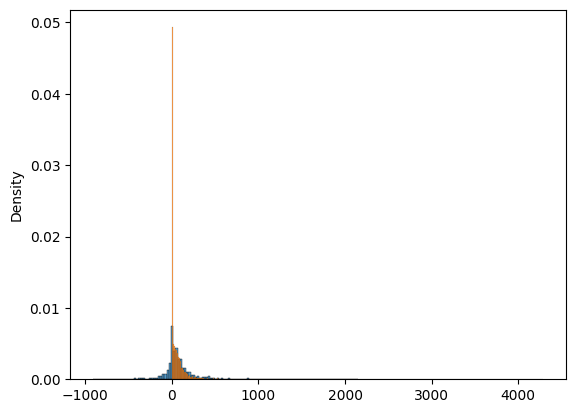

In [ ]:
peptide_idx = 3
stat = "density"
sns.histplot(synth_numerical_inv[:, peptide_idx], stat=stat)
sns.histplot(numerical[:, peptide_idx], stat=stat)